In [1]:
import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import noisereduce as nr
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Reshape,
    LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
SR = 16000
SEGMENT_SECONDS = 3
N_MFCC = 40

DATASET_PATH = "animal_dataset"
OUTPUT_DIR = "result"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded")


d:\Softwares\Anaconda\envs\project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration loaded


In [2]:
def preprocess_audio(path):
    try:
        audio, sr = librosa.load(path, sr=SR, mono=True)


        audio = nr.reduce_noise(y=audio, sr=sr)

        audio, _ = librosa.effects.trim(audio, top_db=20)

        if len(audio) < sr * 0.2:  
            return None

        audio = librosa.util.normalize(audio)

        return audio

    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None



In [3]:
def segment_audio(audio, segment_seconds=3):
    segment_length = SR * segment_seconds
    segments = []
    
    for start in range(0, len(audio) - segment_length, segment_length):
        segments.append(audio[start:start + segment_length])
        
    return segments


In [4]:
def augment_audio(audio):
    augmented = []
    
    augmented.append(audio)
    augmented.append(librosa.effects.pitch_shift(audio, SR, n_steps=2))
    augmented.append(librosa.effects.time_stretch(audio, rate=0.9))
    
    noise = np.random.randn(len(audio)) * 0.005
    augmented.append(audio + noise)
    
    return augmented


In [5]:
MAX_FRAMES = 128
N_MFCC = 40

def pad_or_truncate(feature, max_len=MAX_FRAMES):
    if feature.shape[1] < max_len:
        pad_width = max_len - feature.shape[1]
        return np.pad(feature, ((0,0),(0,pad_width)), mode='constant')
    else:
        return feature[:, :max_len]


def extract_features(audio):
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
    sc = librosa.feature.spectral_centroid(y=audio, sr=SR)
    zcr = librosa.feature.zero_crossing_rate(audio)
    rms = librosa.feature.rms(y=audio)

    mfcc = pad_or_truncate(mfcc)
    sc = pad_or_truncate(sc)
    zcr = pad_or_truncate(zcr)
    rms = pad_or_truncate(rms)

    features = np.vstack([mfcc, sc, zcr, rms])
    return features


In [6]:
X, y = [], []

AUDIO_EXTENSIONS = (".wav", ".mp3", ".flac", ".ogg", ".m4a")

for label in ["Stressed", "Normal"]:
    folder = os.path.join(DATASET_PATH, label)

    for file in os.listdir(folder):
        if file.lower().endswith(AUDIO_EXTENSIONS):
            file_path = os.path.join(folder, file)

            audio = preprocess_audio(file_path)
            segments = segment_audio(audio)

            for seg in segments:
                augmented_segments = augment_audio(seg)
                for aug in augmented_segments:
                    feat = extract_features(aug)
                    if feat is not None:
                        X.append(feat)
                        y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels count:", len(y))


C:\Users\Development\AppData\Local\Temp\ipykernel_19200\2024147951.py:5: FutureWarning: Pass sr=16000 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  augmented.append(librosa.effects.pitch_shift(audio, SR, n_steps=2))


Feature shape: (440, 43, 128)
Labels count: 440


In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X = X[..., np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (352, 43, 128, 1)
Test: (88, 43, 128, 1)


In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Reshape((-1, 64)),
    LSTM(64),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 41, 126, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 20, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 18, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 9, 30, 64)         0         
 g2D)                                                            
                                                                 
 reshape (Reshape)           (None, 270, 64)           0         
                                                                 
 lstm (LSTM)                 (None, 64)                3

In [9]:
# -------------------------------
# Callbacks
# -------------------------------
checkpoint = ModelCheckpoint(
    "best_stress_model.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/100
11/11 [==============================] - ETA: 0s - loss: 0.6756 - accuracy: 0.5881
Epoch 1: val_loss improved from inf to 0.72892, saving model to best_stress_model.h5
11/11 [==============================] - 4s 217ms/step - loss: 0.6756 - accuracy: 0.5881 - val_loss: 0.7289 - val_accuracy: 0.4773 - lr: 0.0010
Epoch 2/100
 1/11 [=>............................] - ETA: 1s - loss: 0.7390 - accuracy: 0.5000

d:\Softwares\Anaconda\envs\project\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


11/11 [==============================] - ETA: 0s - loss: 0.6606 - accuracy: 0.5852
Epoch 2: val_loss improved from 0.72892 to 0.69466, saving model to best_stress_model.h5
11/11 [==============================] - 2s 162ms/step - loss: 0.6606 - accuracy: 0.5852 - val_loss: 0.6947 - val_accuracy: 0.4773 - lr: 0.0010
Epoch 3/100
11/11 [==============================] - ETA: 0s - loss: 0.6412 - accuracy: 0.6051
Epoch 3: val_loss improved from 0.69466 to 0.66536, saving model to best_stress_model.h5
11/11 [==============================] - 2s 159ms/step - loss: 0.6412 - accuracy: 0.6051 - val_loss: 0.6654 - val_accuracy: 0.4773 - lr: 0.0010
Epoch 4/100
11/11 [==============================] - ETA: 0s - loss: 0.6266 - accuracy: 0.6420
Epoch 4: val_loss improved from 0.66536 to 0.62989, saving model to best_stress_model.h5
11/11 [==============================] - 2s 162ms/step - loss: 0.6266 - accuracy: 0.6420 - val_loss: 0.6299 - val_accuracy: 0.6364 - lr: 0.0010
Epoch 5/100
11/11 [=========

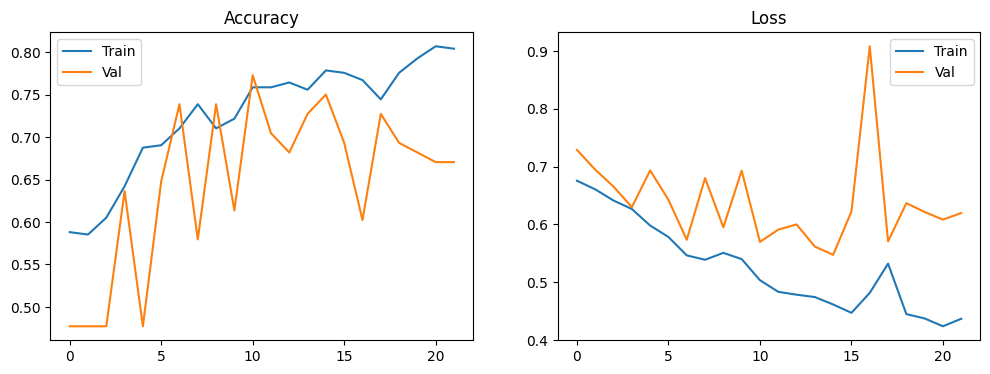

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Val"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Val"])

plt.savefig(f"{OUTPUT_DIR}/training_curves.png")
plt.show()


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

y_pred = (model.predict(X_test) > 0.5).astype(int).ravel()
y_true = y_test.ravel()

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))



3/3 [==============================] - 1s 47ms/step
Accuracy : 0.75
Precision: 0.75
Recall   : 0.782608695652174
F1 Score : 0.7659574468085107


In [13]:
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


Confusion Matrix:
 [[30 12]
 [10 36]]


In [14]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred,
                            target_names=["Normal", "Stressed"]))


Classification Report:

              precision    recall  f1-score   support

      Normal       0.75      0.71      0.73        42
    Stressed       0.75      0.78      0.77        46

    accuracy                           0.75        88
   macro avg       0.75      0.75      0.75        88
weighted avg       0.75      0.75      0.75        88



In [15]:
model.save(f"{OUTPUT_DIR}/stress_model1.h5")
print("Model saved")


Model saved


d:\Softwares\Anaconda\envs\project\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [16]:
def predict_stress(path):
    audio = preprocess_audio(path)
    segments = segment_audio(audio)
    
    preds = []
    for seg in segments:
        feat = extract_features(seg)
        feat = feat[np.newaxis, ..., np.newaxis]
        pred = model.predict(feat)[0][0]
        preds.append(pred)
        
    mean_pred = np.mean(preds)
    stress_class = "Stressed" if mean_pred > 0.5 else "Normal"
    stress_intensity = int(mean_pred * 100)
    
    return stress_class, stress_intensity


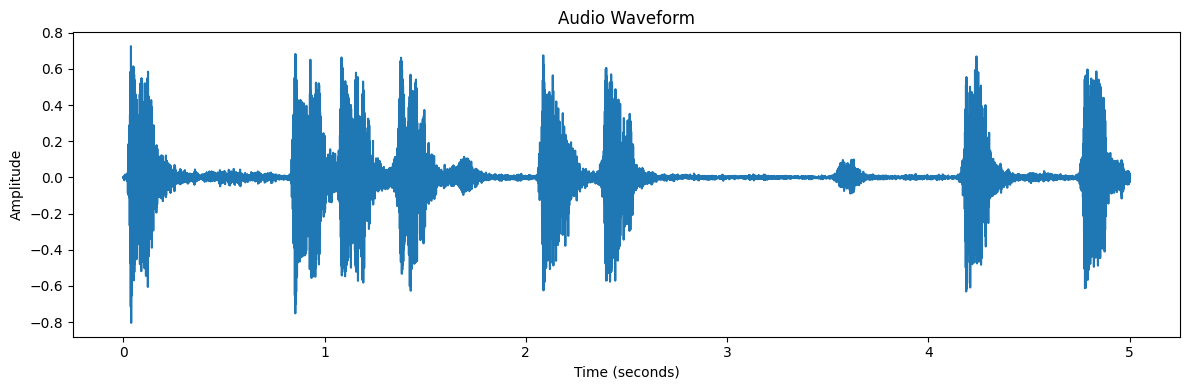

In [27]:
test_audio = "animal_mood_dataset\\Normal\\dog_bark_dog_2.wav"

audio, sr = librosa.load(test_audio, sr=SR)

time = np.linspace(0, len(audio)/sr, num=len(audio))

plt.figure(figsize=(12,4))
plt.plot(time, audio)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.tight_layout()
plt.show()



In [28]:
cls, intensity = predict_stress(test_audio)

print("Predicted Stress Class:", cls)
print("Stress Intensity:", intensity, "/100")


1/1 [==============================] - 0s 40ms/step
Predicted Stress Class: Normal
Stress Intensity: 8 /100


In [32]:
# Load the trained model
print("Loading trained model...")
model = tf.keras.models.load_model("best_stress_model.h5")
print("Model loaded successfully!")
model.summary()


Loading trained model...
Model loaded successfully!
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 41, 126, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 20, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 18, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 9, 30, 64)         0         
 g2D)                                                            
                                                                 
 reshape (Reshape)           (None, 270, 64)           0         
                                                                 
 lst

In [33]:
import shutil
from pathlib import Path

# Create output folder structure
CORRECTLY_PREDICTED_DIR = "correctly_predicted"
os.makedirs(os.path.join(CORRECTLY_PREDICTED_DIR, "Stressed"), exist_ok=True)
os.makedirs(os.path.join(CORRECTLY_PREDICTED_DIR, "Normal"), exist_ok=True)

# Test all audio files and save correctly predicted ones
test_results = []
correct_count = 0
total_count = 0

AUDIO_EXTENSIONS = (".wav", ".mp3", ".flac", ".ogg", ".m4a")

for true_label in ["Stressed", "Normal"]:
    folder = os.path.join(DATASET_PATH, true_label)
    
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        continue
    
    for file in os.listdir(folder):
        if file.lower().endswith(AUDIO_EXTENSIONS):
            file_path = os.path.join(folder, file)
            total_count += 1
            
            try:
                # Predict
                pred_class, pred_intensity = predict_stress(file_path)
                
                # Check if prediction is correct
                is_correct = (pred_class == true_label)
                
                if is_correct:
                    correct_count += 1
                    # Copy file to correctly_predicted folder
                    dest_path = os.path.join(CORRECTLY_PREDICTED_DIR, pred_class, file)
                    shutil.copy2(file_path, dest_path)
                    print(f"✓ {file} ({true_label}) -> {pred_class} [CORRECT]")
                else:
                    print(f"✗ {file} ({true_label}) -> {pred_class} [WRONG]")
                
                test_results.append({
                    "filename": file,
                    "true_label": true_label,
                    "predicted_label": pred_class,
                    "intensity": pred_intensity,
                    "correct": is_correct
                })
                
            except Exception as e:
                print(f"Error processing {file}: {e}")

print("\n" + "="*60)
print(f"TESTING COMPLETE")
print(f"Total files tested: {total_count}")
print(f"Correctly predicted: {correct_count}")
print(f"Accuracy: {(correct_count/total_count*100):.2f}%")
print(f"Saved to: {CORRECTLY_PREDICTED_DIR}/")
print("="*60)

1/1 [==============================] - 0s 418ms/step
✓ Angry_car_extcoll0156.mp3 (Stressed) -> Stressed [CORRECT]
1/1 [==============================] - 0s 44ms/step
✓ Angry_car_extcoll0162.mp3 (Stressed) -> Stressed [CORRECT]
Error processing Angry_car_extcoll0169.mp3: cannot convert float NaN to integer
Error processing Angry_car_extcoll0171.mp3: cannot convert float NaN to integer
1/1 [==============================] - 0s 34ms/step
✓ Angry_car_extcoll0172.mp3 (Stressed) -> Stressed [CORRECT]
1/1 [==============================] - 0s 31ms/step
✓ Angry_car_extcoll0174.mp3 (Stressed) -> Stressed [CORRECT]
1/1 [==============================] - 0s 31ms/step
✓ Angry_car_extcoll0175.mp3 (Stressed) -> Stressed [CORRECT]
1/1 [==============================] - 0s 31ms/step
✓ Angry_car_extcoll0177.mp3 (Stressed) -> Stressed [CORRECT]
1/1 [==============================] - 0s 31ms/step
✓ Angry_car_extcoll0191.mp3 (Stressed) -> Stressed [CORRECT]
1/1 [==============================] - 0s 32ms/s